## KPI & Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

with open("../config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

ship = pd.read_csv("../data/processed/shipments_simulated.csv")
lanes = pd.read_csv("../data/processed/lanes_generated.csv")

ship.head()

,retailer_id,sku_id,week,demand_units,realized_lead_days,delivered_on_time,transport_cost
0,RET_1,SKU_1,1,0.00,16,True,0.00
1,RET_1,SKU_1,2,0.00,16,True,0.00
2,RET_1,SKU_1,3,0.00,16,True,0.00
3,RET_1,SKU_1,4,0.00,19,False,0.00
4,RET_1,SKU_1,5,0.00,16,True,0.00


In [2]:
expected_base_days = lanes["base_lead_days"].mean()
expected_base_days

np.float64(5.333333333333333)

In [3]:
ship["expected_lead_days"] = expected_base_days
ship["delay_days"] = (ship["realized_lead_days"] - ship["expected_lead_days"]).clip(lower=0)
ship["cost_per_unit"] = ship["transport_cost"] / ship["demand_units"].replace(0, np.nan)
ship["on_time_flag"] = ship["delivered_on_time"].astype(int)

ship.describe(include="all").T.head(12)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
retailer_id,936,6,RET_1,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku_id,936,3,SKU_1,312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
week,936.00,NaN,NaN,NaN,26.50,15.02,1.00,13.75,26.50,39.25,52.00
demand_units,936.00,NaN,NaN,NaN,11.62,41.55,0.00,0.00,0.00,0.00,222.26
realized_lead_days,936.00,NaN,NaN,NaN,16.46,1.01,16.00,16.00,16.00,16.00,22.00
delivered_on_time,936,2,True,746,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transport_cost,936.00,NaN,NaN,NaN,29.47,106.45,0.00,0.00,0.00,0.00,678.87
expected_lead_days,936.00,NaN,NaN,NaN,5.33,0.00,5.33,5.33,5.33,5.33,5.33
delay_days,936.00,NaN,NaN,NaN,11.12,1.01,10.67,10.67,10.67,10.67,16.67
cost_per_unit,72.00,NaN,NaN,NaN,2.54,0.40,2.03,2.21,2.39,2.95,3.12


In [4]:
def kpi_agg(df):
    return pd.Series({
        "shipments": len(df),
        "units": df["demand_units"].sum(),
        "otd_pct": df["on_time_flag"].mean() * 100,
        "avg_lead_days": df["realized_lead_days"].mean(),
        "avg_delay_days": df["delay_days"].mean(),
        "total_cost": df["transport_cost"].sum(),
        "cost_per_unit_avg": (df["transport_cost"].sum() / max(df["demand_units"].sum(), 1))
    })

In [5]:
kpi_overall = kpi_agg(ship)
kpi_by_week = ship.groupby("week").apply(kpi_agg).reset_index()
kpi_by_retailer = ship.groupby("retailer_id").apply(kpi_agg).reset_index()
kpi_by_sku = ship.groupby("sku_id").apply(kpi_agg).reset_index()

kpi_overall, kpi_by_week.head(), kpi_by_retailer.head(), kpi_by_sku.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15324\1530174520.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kpi_by_week = ship.groupby("week").apply(kpi_agg).reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15324\1530174520.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kpi_by_retailer = ship.groupby("retailer_id").apply(kpi_agg).reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_15324\15301

(shipments              936.00
 units               10,880.06
 otd_pct                 79.70
 avg_lead_days           16.46
 avg_delay_days          11.12
 total_cost          27,580.41
 cost_per_unit_avg        2.53
 dtype: float64,
    week  shipments  units  otd_pct  avg_lead_days  avg_delay_days  total_cost  \
 0     1      18.00   0.00    83.33          16.56           11.22        0.00   
 1     2      18.00 108.58    77.78          16.39           11.06      259.51   
 2     3      18.00   0.00    72.22          16.50           11.17        0.00   
 3     4      18.00 179.92    83.33          16.56           11.22      527.18   
 4     5      18.00 566.68    94.44          16.11           10.78    1,320.93   
 
    cost_per_unit_avg  
 0               0.00  
 1               2.39  
 2               0.00  
 3               2.93  
 4               2.33  ,
   retailer_id  shipments    units  otd_pct  avg_lead_days  avg_delay_days  \
 0       RET_1     156.00 1,787.82    76.92      

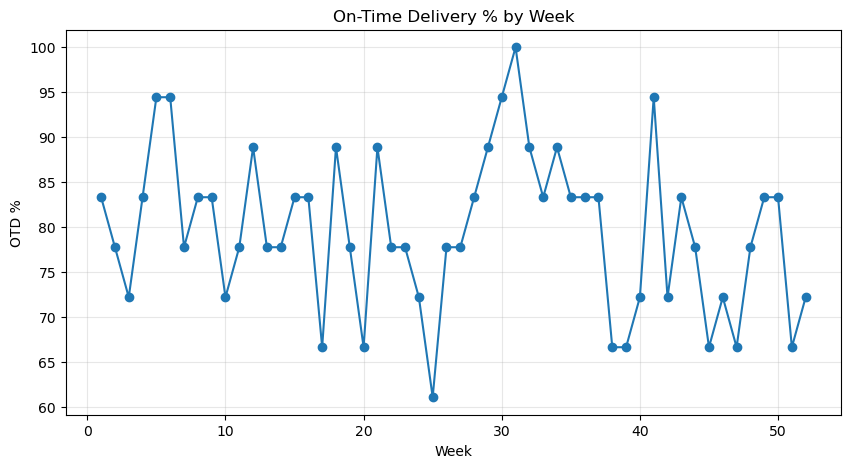

In [6]:
plt.figure(figsize=(10,5))
plt.plot(kpi_by_week["week"], kpi_by_week["otd_pct"], marker="o")
plt.title("On-Time Delivery % by Week")
plt.xlabel("Week"); plt.ylabel("OTD %"); plt.grid(alpha=0.3); plt.show()

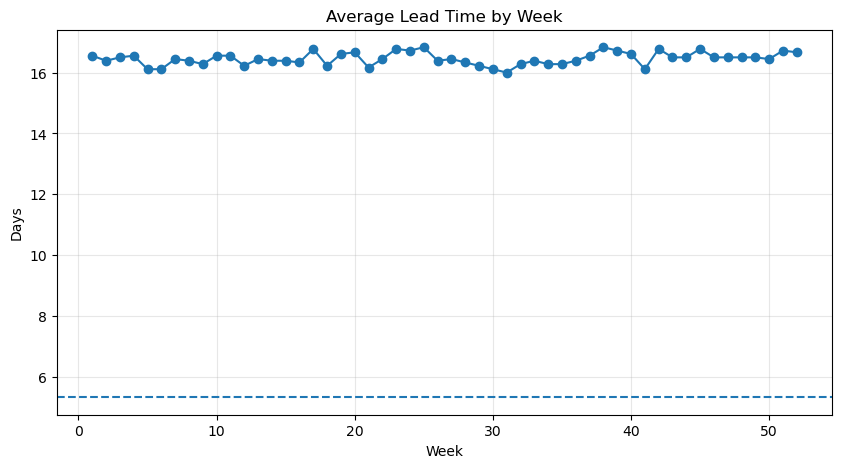

In [7]:
plt.figure(figsize=(10,5))
plt.plot(kpi_by_week["week"], kpi_by_week["avg_lead_days"], marker="o")
plt.axhline(expected_base_days, linestyle="--")
plt.title("Average Lead Time by Week")
plt.xlabel("Week"); plt.ylabel("Days"); plt.grid(alpha=0.3); plt.show()

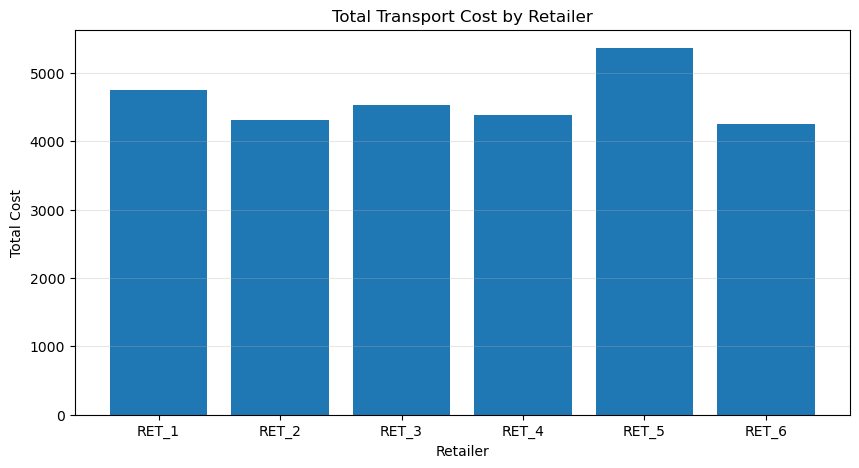

In [8]:
plt.figure(figsize=(10,5))
plt.bar(kpi_by_retailer["retailer_id"], kpi_by_retailer["total_cost"])
plt.title("Total Transport Cost by Retailer")
plt.xlabel("Retailer"); plt.ylabel("Total Cost"); plt.grid(axis="y", alpha=0.3); plt.show()

In [9]:
out_dir = Path("../data/processed"); out_dir.mkdir(parents=True, exist_ok=True)
kpi_by_week.to_csv(out_dir/"kpi_by_week.csv", index=False)
kpi_by_retailer.to_csv(out_dir/"kpi_by_retailer.csv", index=False)
kpi_by_sku.to_csv(out_dir/"kpi_by_sku.csv", index=False)

summary = pd.DataFrame([kpi_overall]).round(2)
summary.to_csv(out_dir/"kpi_summary.csv", index=False)
print("✅ Saved KPI outputs to data/processed/")
summary

✅ Saved KPI outputs to data/processed/


,shipments,units,otd_pct,avg_lead_days,avg_delay_days,total_cost,cost_per_unit_avg
0,936.00,"10,880.06",79.70,16.46,11.12,"27,580.41",2.53
